In [14]:
import tensorflow as tf
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import os
import pandas as pd

In [ ]:
# Configuration
base_dir = "Cinnamon_Master_Dataset"
img_size = (224, 224)
batch_size = 32
num_classes = 8

FILE_COL = 'filename' 
LABEL_COL = 'label' 

In [16]:
MASTER_CLASS_MAP = {
    "healthy_leaves": 0, "healthystem": 0, "cinnamon_stem": 0, "unlabeled": 0, 
    "leaf_spot_disease": -1,
    "leaf-spot-low-stage": 1, "lowstage_leafspot_cinnamon": 1,
    "leaf-spot-medium-stage": 2, "mediumstage_leafspot_cinnamon": 2,
    "leaf-spot-high-stage": 3, "highstage_leafspot_cinnamon": 3,
    "roughbark": 4,              
    "stripecanker": -1,
    "stripe-canker-low-stage": 5, "lowstage_stripecanker_cinnamon": 5,
    "stripe-canker-medium-stage": 6, "mediumstage_stripecanker_cinnamon": 6,
    "stripe-canker-high-stage": 7, "highstage_stripecanker_cinnamon": 7
}

# Mapping for the verification print statements
idx_to_name = {
    0: "Healthy", 1: "LS-Low", 2: "LS-Med", 3: "LS-High",
    4: "RoughBark", 5: "SC-Low", 6: "SC-Med", 7: "SC-High"
}

In [ ]:
# Load Metadata & Prepare Paths
def prepare_dataframe(split_name):
    csv_path = os.path.join(base_dir, split_name, 'metadata.csv')
    img_dir = os.path.join(base_dir, split_name, 'images')
    
    df = pd.read_csv(csv_path)
    df['filepath'] = df[FILE_COL].apply(lambda x: os.path.join(img_dir, str(x)))
    
    # Apply the MASTER_CLASS_MAP
    df['label_idx'] = df[LABEL_COL].map(MASTER_CLASS_MAP)
    
    # Drop rows that are mapped to -1 (generic categories without severity)
    initial_count = len(df)
    df = df[df['label_idx'] != -1].reset_index(drop=True)
    if len(df) < initial_count:
        print(f"Dropped {initial_count - len(df)} samples with generic/unusable labels from {split_name}")
        
    return df

train_df = prepare_dataframe('train')
val_df = prepare_dataframe('val') 
test_df = prepare_dataframe('test')

In [ ]:
# Class Imbalance Handling
print("Calculating class weights from training metadata")
train_labels = train_df['label_idx'].values

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights_dict = dict(enumerate(class_weights_array))
print("Class Weights Dictionary:", class_weights_dict)

Calculating class weights from training metadata...
Class Weights Dictionary: {0: np.float64(0.8474604221635884), 1: np.float64(1.0548029556650247), 2: np.float64(1.6994047619047619), 3: np.float64(1.6221590909090908), 4: np.float64(1.504391100702576), 5: np.float64(0.695211038961039), 6: np.float64(0.5339775561097256), 7: np.float64(1.4467905405405406)}


In [ ]:
# High-Performance tf.data Pipeline
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False) 
    img = tf.image.resize(img, img_size)
    label = tf.one_hot(tf.cast(label, tf.int32), depth=num_classes)
    return img, label

def create_dataset(df, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((df['filepath'].values, df['label_idx'].values))
    if is_training:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.cache().prefetch(buffer_size=AUTOTUNE)
    return ds

print("Building datasets")
train_ds = create_dataset(train_df, is_training=True)
val_ds = create_dataset(val_df, is_training=False)
test_ds = create_dataset(test_df, is_training=False)

Building datasets...


In [ ]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2)
], name="augmentation_layer")

In [ ]:
# Pipeline Verification
print("Dataset Verification")
print(f"Target Output Classes: {idx_to_name}")

for images, labels in train_ds.take(1):
    print(f"Image batch shape: {images.shape}") 
    print(f"Label batch shape: {labels.shape}") 
    
    print("\nFirst 5 samples in this batch (Mapped):")
    for i in range(5):
        class_idx = np.argmax(labels[i].numpy())
        readable_name = idx_to_name[class_idx]
        
        img_min = np.min(images[i].numpy())
        img_max = np.max(images[i].numpy())
        
        print(f"  Sample {i+1}: Mapped_Class='{readable_name}' (Index {class_idx}), Range=[{img_min:.1f}, {img_max:.1f}]")

print(f"\nTotal Training Batches: {len(train_ds)}")
print(f"Total Validation Batches: {len(val_ds)}")


--- Dataset Verification (Mapped Classes) ---
Target Output Classes: {0: 'Healthy', 1: 'LS-Low', 2: 'LS-Med', 3: 'LS-High', 4: 'RoughBark', 5: 'SC-Low', 6: 'SC-Med', 7: 'SC-High'}
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 8)

First 5 samples in this batch (Mapped):
  Sample 1: Mapped_Class='SC-Med' (Index 6), Range=[0.0, 255.0]
  Sample 2: Mapped_Class='Healthy' (Index 0), Range=[0.0, 238.1]
  Sample 3: Mapped_Class='LS-Med' (Index 2), Range=[0.0, 247.4]
  Sample 4: Mapped_Class='SC-Med' (Index 6), Range=[0.0, 255.0]
  Sample 5: Mapped_Class='LS-High' (Index 3), Range=[0.0, 255.0]

Total Training Batches: 161
Total Validation Batches: 13


In [ ]:
import tensorflow as tf

# Load the lightweight pre-trained base
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
# Initial freeze for transfer learning
base_model.trainable = False  

model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2), # 
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Start Phase 1 training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights_dict, # Applied to handle data imbalance
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 3s 1us/step
Epoch 1/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 118s 680ms/step - accuracy: 0.4258 - loss: 1.4368 - val_accuracy: 0.4729 - val_loss: 1.1938
Epoch 2/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 66s 409ms/step - accuracy: 0.5834 - loss: 1.0020 - val_accuracy: 0.5517 - val_loss: 1.0987
Epoch 3/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 64s 394ms/step - accuracy: 0.6170 - loss: 0.8958 - val_accuracy: 0.6034 - val_loss: 1.0232
Epoch 4/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 60s 372ms/step - accuracy: 0.6410 - loss: 0.8216 - val_accuracy: 0.5961 - val_loss: 1.0217
Epoch 5/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 55s 340ms/step - accuracy: 0.6610 - loss: 0.7850 - val_accuracy: 0.6182 - val_loss: 0.9679
Epoch 6/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 55s 341ms/step - accuracy: 0.6669 - loss: 0.7560 - val_accuracy: 0.6404 - val_loss: 0.9634
Epoch 7/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 54s 335ms/step - accuracy: 0.6727 - loss: 0.7296 - val_accuracy: 0.6773 - val_loss: 0.9218
Epoch 8/15
161/161 ━━━━━━━━━━━━━━

In [ ]:
import numpy as np
from sklearn.metrics import classification_report


# Unfreeze the base model
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total layers in base model: {len(base_model.layers)}")
print(f"Fine-tuning the top {len(base_model.layers) - fine_tune_at} layers.")

# Recompile with a much lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resume Training
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

print("Model Evaluation")

# Evaluate on the Test Dataset
test_loss, test_acc = model.evaluate(test_ds)
print(f"Final Test Accuracy: {test_acc:.4f}")

# Generate a Classification Report to check Severity Grading performance
print("\nClassification Report.")
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

print(classification_report(y_true, y_pred, target_names=[idx_to_name[i] for i in range(8)]))

# Convert to TFLite with Post-Training Quantization
# This compresses the model so it runs efficiently offline on low-end smartphones
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] 
tflite_model = converter.convert()

tflite_filename = 'cinnamon_disease_severity_model.tflite'
with open(tflite_filename, 'wb') as f:
    f.write(tflite_model)

print(f"Successfully exported highly compressed model to: {tflite_filename}")

Total layers in base model: 157
Fine-tuning the top 30 layers.
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 112s 546ms/step - accuracy: 0.5865 - loss: 0.9286 - val_accuracy: 0.7217 - val_loss: 0.8598
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 76s 474ms/step - accuracy: 0.6239 - loss: 0.8080 - val_accuracy: 0.7143 - val_loss: 0.8690
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 73s 455ms/step - accuracy: 0.6495 - loss: 0.7550 - val_accuracy: 0.7217 - val_loss: 0.8772
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 71s 442ms/step - accuracy: 0.6678 - loss: 0.7164 - val_accuracy: 0.7192 - val_loss: 0.8813

--- Model Evaluation ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 565ms/step - accuracy: 0.6906 - loss: 0.7556
Final Test Accuracy: 0.6906

Generating Classification Report...
              precision    recall  f1-score   support

     Healthy       0.98      0.80      0.88        74
      LS-Low       0.53      0.68      0.59        28
      LS-Med       0.67      0.53      0.59        15
     LS-High       0.91      0.

INFO:tensorflow:Assets written to: C:\Users\wickn\AppData\Local\Temp\tmpoq_hvkl_\assets


Saved artifact at 'C:\Users\wickn\AppData\Local\Temp\tmpoq_hvkl_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_175')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  3130031226944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129934607840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129934601152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129934605024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129934605904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129934596400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129942340032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129934594112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129934596928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129942333344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3

Generating Grad-CAM visualization for Explainable AI
True Class: Healthy
Predicted Class: RoughBark
Confidence: 99.98%


C:\Users\wickn\AppData\Local\Temp\ipykernel_9184\2679893756.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("jet")


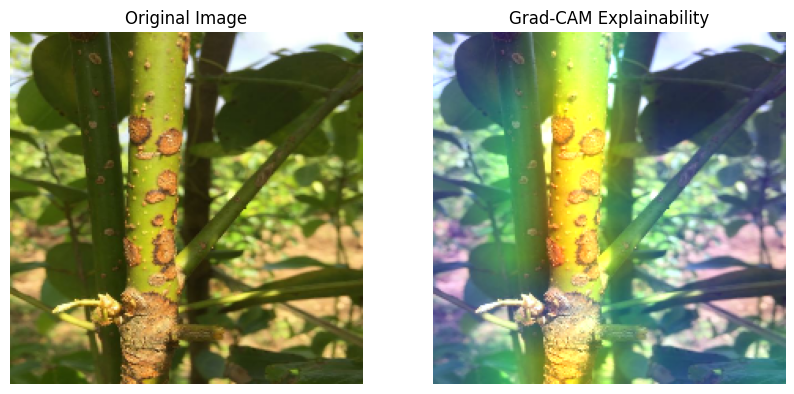

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Isolate the base model
    base_model = model.get_layer("MobileNetV3Small")
    
    # Build a sub-model that outputs both the target conv layer AND the base model's final output
    grad_model = tf.keras.models.Model(
        inputs=base_model.inputs, 
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )
    
    # Gather the classification head layers
    base_idx = model.layers.index(base_model)
    head_layers = model.layers[base_idx + 1:]
    
    with tf.GradientTape() as tape:
        # Pass the image through the base model 
        last_conv_layer_output, intermediate_output = grad_model(img_array)
        
        # Explicitly tell the tape to watch the convolutional feature map
        tape.watch(last_conv_layer_output)
        
        # Manually pass the data through the classification head
        preds = intermediate_output
        for layer in head_layers:
            preds = layer(preds)
            
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
            
        class_channel = preds[:, pred_index]

    # Compute gradients of the predicted class with respect to the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Generate and normalize the heatmap
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

def display_gradcam(img_tensor, heatmap, alpha=0.4):
    # Convert tensor to image format
    img = img_tensor.numpy().astype("uint8")

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    colormap = cm.get_cmap("jet")
    colormap_colors = colormap(np.arange(256))[:, :3]
    jet_heatmap = colormap_colors[heatmap]

    jet_heatmap = tf.image.resize(jet_heatmap, (img.shape[0], img.shape[1])).numpy()
    
    # Scale heatmap to 0-255 to match the original image
    jet_heatmap = jet_heatmap * 255

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    
    # Clip values to ensure they stay in standard image format [0, 255]
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")

    # Display the result
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Explainability")
    plt.axis("off")
    
    plt.show()

print("Generating Grad-CAM visualization for Explainable AI")

last_conv_layer = "conv_1"

# Grab one batch from the test dataset
for images, labels in test_ds.take(1):
    # Select the first image in the batch
    test_img = images[1]
    true_label_idx = np.argmax(labels[0].numpy())
    
    # Expand dimensions to create a batch of 1
    test_img_batch = tf.expand_dims(test_img, axis=0)
    
    # Get model prediction
    preds = model.predict(test_img_batch, verbose=0)
    pred_idx = np.argmax(preds[0])
    
    print(f"True Class: {idx_to_name[true_label_idx]}")
    print(f"Predicted Class: {idx_to_name[pred_idx]}")
    print(f"Confidence: {preds[0][pred_idx] * 100:.2f}%")
    
    # Generate and display heatmap
    heatmap = make_gradcam_heatmap(test_img_batch, model, last_conv_layer)
    display_gradcam(test_img, heatmap)
    
    break 